# Speed Dating Data 数据分析报告

## 目录
1. 数据描述
2. 数据转换
3. 缺失值处理
4. 异常值处理

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

---

## 1. 数据描述

### 1.1 数据结构和基本信息

In [2]:
# 读取数据集
data = pd.read_csv('Speed Dating Data.csv', encoding='latin1')

# 查看数据形状
print(f"数据集形状: {data.shape}")
print(f"样本数量: {data.shape[0]}")
print(f"特征数量: {data.shape[1]}")

数据集形状: (8378, 195)
样本数量: 8378
特征数量: 195


In [3]:
# 查看数据类型分布
dtype_counts = data.dtypes.value_counts()
print("\n数据类型分布:")
print(dtype_counts)

# 查看前5行数据
print("\n前5行数据:")
display(data.head())


数据类型分布:
float64    174
int64       13
object       8
Name: count, dtype: int64

前5行数据:


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


### 1.2 列名说明

根据数据集说明文档，主要列名含义如下：
- `iid`: 个体唯一标识
- `id`: 波次内的参与者编号
- `gender`: 性别 (0=女, 1=男)
- `match`: 是否匹配 (0=否, 1=是)
- `age`: 年龄
- `race`: 种族
- `attr`: 对方吸引力评分
- `sinc`: 对方真诚度评分
- `intel`: 对方智力评分
- `fun`: 对方有趣度评分
- `amb`: 对方抱负评分
- `shar`: 共同兴趣评分
- `like`: 喜欢程度
- `prob`: 再次见面概率
- `met`: 是否见过面

In [4]:
# 查看所有列名
print("\n所有列名:")
for i, col in enumerate(data.columns, 1):
    print(f"{i:3d}. {col}")


所有列名:
  1. iid
  2. id
  3. gender
  4. idg
  5. condtn
  6. wave
  7. round
  8. position
  9. positin1
 10. order
 11. partner
 12. pid
 13. match
 14. int_corr
 15. samerace
 16. age_o
 17. race_o
 18. pf_o_att
 19. pf_o_sin
 20. pf_o_int
 21. pf_o_fun
 22. pf_o_amb
 23. pf_o_sha
 24. dec_o
 25. attr_o
 26. sinc_o
 27. intel_o
 28. fun_o
 29. amb_o
 30. shar_o
 31. like_o
 32. prob_o
 33. met_o
 34. age
 35. field
 36. field_cd
 37. undergra
 38. mn_sat
 39. tuition
 40. race
 41. imprace
 42. imprelig
 43. from
 44. zipcode
 45. income
 46. goal
 47. date
 48. go_out
 49. career
 50. career_c
 51. sports
 52. tvsports
 53. exercise
 54. dining
 55. museums
 56. art
 57. hiking
 58. gaming
 59. clubbing
 60. reading
 61. tv
 62. theater
 63. movies
 64. concerts
 65. music
 66. shopping
 67. yoga
 68. exphappy
 69. expnum
 70. attr1_1
 71. sinc1_1
 72. intel1_1
 73. fun1_1
 74. amb1_1
 75. shar1_1
 76. attr4_1
 77. sinc4_1
 78. intel4_1
 79. fun4_1
 80. amb4_1
 81. shar4_1
 82. att

### 1.3 统计摘要分析

In [5]:
# 数值型数据的统计摘要
print("\n数值型数据统计摘要:")
display(data.describe().round(2))


数值型数据统计摘要:


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
count,8378.00,8377.00,8378.0,8378.00,8378.00,8378.00,8378.00,8378.00,6532.00,8378.00,...,3974.00,3974.00,3974.00,3974.00,3974.00,2016.00,2016.00,2016.00,2016.00,2016.00
mean,283.68,8.96,0.5,17.33,1.83,11.35,16.87,9.04,9.30,8.93,...,7.24,8.09,8.39,7.66,7.39,6.81,7.62,7.93,7.16,7.05
std,158.58,5.49,0.5,10.94,0.38,6.00,4.36,5.51,5.65,5.48,...,1.58,1.61,1.46,1.74,1.96,1.51,1.50,1.34,1.67,1.72
min,1.00,1.00,0.0,1.00,1.00,1.00,5.00,1.00,1.00,1.00,...,2.00,2.00,3.00,2.00,1.00,2.00,2.00,4.00,1.00,1.00
25%,154.00,4.00,0.0,8.00,2.00,7.00,14.00,4.00,4.00,4.00,...,7.00,7.00,8.00,7.00,6.00,6.00,7.00,7.00,6.00,6.00
50%,281.00,8.00,1.0,16.00,2.00,11.00,18.00,8.00,9.00,8.00,...,7.00,8.00,8.00,8.00,8.00,7.00,8.00,8.00,7.00,7.00
75%,407.00,13.00,1.0,26.00,2.00,15.00,20.00,13.00,14.00,13.00,...,8.00,9.00,9.00,9.00,9.00,8.00,9.00,9.00,8.00,8.00
max,552.00,22.00,1.0,44.00,2.00,21.00,22.00,22.00,22.00,22.00,...,12.00,12.00,12.00,12.00,12.00,10.00,10.00,10.00,10.00,10.00


In [6]:
# 分类变量的频率统计
print("\n性别分布:")
print(data['gender'].value_counts())
print("\n匹配情况分布:")
print(data['match'].value_counts())
print("\n种族分布:")
print(data['race'].value_counts())


性别分布:
gender
1    4194
0    4184
Name: count, dtype: int64

匹配情况分布:
match
0    6998
1    1380
Name: count, dtype: int64

种族分布:
race
2.0    4727
4.0    1982
3.0     664
6.0     522
1.0     420
Name: count, dtype: int64


### 1.4 数据质量评估

In [7]:
# 计算缺失值比例
missing_ratio = (data.isnull().sum() / len(data)) * 100
missing_ratio = missing_ratio.sort_values(ascending=False)

print("\n缺失值比例前20的列:")
display(missing_ratio.head(20).round(2))


缺失值比例前20的列:


num_in_3    92.03
numdat_3    82.14
expnum      78.52
sinc7_2     76.67
amb7_2      76.67
shar7_2     76.44
attr7_2     76.32
fun7_2      76.32
intel7_2    76.32
fun5_3      75.94
amb5_3      75.94
shar2_3     75.94
attr5_3     75.94
amb7_3      75.94
shar7_3     75.94
sinc5_3     75.94
sinc7_3     75.94
intel7_3    75.94
fun7_3      75.94
attr7_3     75.94
dtype: float64

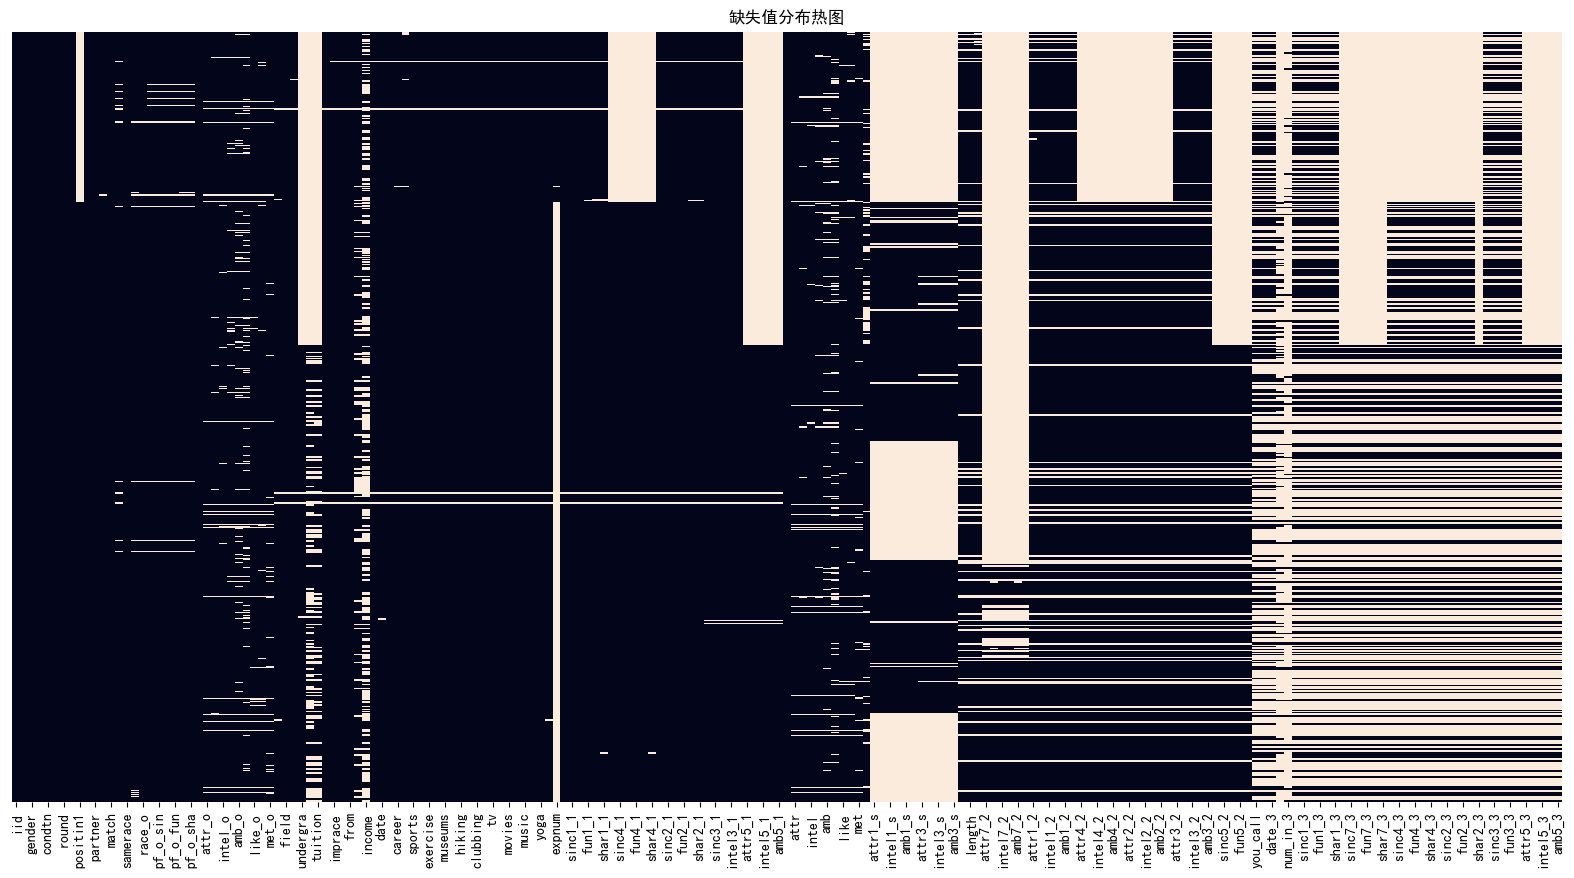

In [8]:
# 绘制缺失值热图
plt.figure(figsize=(20, 10))
sns.heatmap(data.isnull(), cbar=False, yticklabels=False)
plt.title('缺失值分布热图')
plt.show()

In [9]:
# 检查重复数据
duplicate_count = data.duplicated().sum()
print(f"\n重复记录数量: {duplicate_count}")

# 检查数据类型是否合理
print("\n数据类型检查:")
print(data.dtypes.head(20))


重复记录数量: 0

数据类型检查:
iid           int64
id          float64
gender        int64
idg           int64
condtn        int64
wave          int64
round         int64
position      int64
positin1    float64
order         int64
partner       int64
pid         float64
match         int64
int_corr    float64
samerace      int64
age_o       float64
race_o      float64
pf_o_att    float64
pf_o_sin    float64
pf_o_int    float64
dtype: object


---

## 2. 数据转换

### 2.1 数据类型转换

根据数据含义，需要将部分列转换为合适的数据类型：
- `gender`, `match`, `samerace`, `dec`, `dec_o` 应转换为类别型
- `race`, `field_cd`, `career_c` 应转换为类别型


In [10]:
# 创建数据副本进行转换
data_cleaned = data.copy()

# 转换为类别型的列
categorical_cols = ['gender', 'match', 'samerace', 'dec', 'dec_o', 
                   'race', 'race_o', 'field_cd', 'career_c', 'condtn', 
                   'wave','undergra', 'tuition', 'mn_sat', 'zipcode', 
                   'from', 'career', 'field']

for col in categorical_cols:
    if col in data_cleaned.columns:
        data_cleaned[col] = data_cleaned[col].astype('category')
        
data_cleaned['income'] = data_cleaned['income'].str.replace(',', '')  # 只需要去除逗号
data_cleaned['income'] = pd.to_numeric(data_cleaned['income'], errors='coerce')

# 查看转换后的数据类型
print("转换后的数据类型:")
print(data_cleaned[categorical_cols].dtypes)
print(data_cleaned['income'].dtypes)


转换后的数据类型:
gender      category
match       category
samerace    category
dec         category
dec_o       category
race        category
race_o      category
field_cd    category
career_c    category
condtn      category
wave        category
undergra    category
tuition     category
mn_sat      category
zipcode     category
from        category
career      category
field       category
dtype: object
float64


### 2.2 数据清洗和过滤

#### 2.2.1 去除重复数据

In [11]:
# 检查并去除重复数据
print(f"去重前记录数: {len(data_cleaned)}")
data_cleaned = data_cleaned.drop_duplicates()
print(f"去重后记录数: {len(data_cleaned)}")

去重前记录数: 8378
去重后记录数: 8378


---

## 3. 缺失值处理

### 3.1 缺失值分析

首先分析不同类型变量的缺失情况，然后选择合适的插补方法：
- 数值型变量：使用均值、中位数或众数插补
- 类别型变量：使用众数插补或创建新类别
- 高缺失率的列：考虑删除

In [12]:
# 重新计算缺失值比例
missing_ratio = (data_cleaned.isnull().sum() / len(data_cleaned)) * 100

# 高缺失率列（缺失率>50%）
high_missing_cols = missing_ratio[missing_ratio > 50].index.tolist()
print(f"缺失率>50%的列数: {len(high_missing_cols)}")
print("\n高缺失率列:")
for col in high_missing_cols:
    print(f"  {col}: {missing_ratio[col]:.1f}%")

缺失率>50%的列数: 59

高缺失率列:
  mn_sat: 62.6%
  tuition: 57.2%
  expnum: 78.5%
  attr1_s: 51.1%
  sinc1_s: 51.1%
  intel1_s: 51.1%
  fun1_s: 51.1%
  amb1_s: 51.1%
  shar1_s: 51.1%
  attr3_s: 52.3%
  sinc3_s: 52.3%
  intel3_s: 52.3%
  fun3_s: 52.3%
  amb3_s: 52.3%
  attr7_2: 76.3%
  sinc7_2: 76.7%
  intel7_2: 76.3%
  fun7_2: 76.3%
  amb7_2: 76.7%
  shar7_2: 76.4%
  you_call: 52.6%
  them_cal: 52.6%
  date_3: 52.6%
  numdat_3: 82.1%
  num_in_3: 92.0%
  attr1_3: 52.6%
  sinc1_3: 52.6%
  intel1_3: 52.6%
  fun1_3: 52.6%
  amb1_3: 52.6%
  shar1_3: 52.6%
  attr7_3: 75.9%
  sinc7_3: 75.9%
  intel7_3: 75.9%
  fun7_3: 75.9%
  amb7_3: 75.9%
  shar7_3: 75.9%
  attr4_3: 64.7%
  sinc4_3: 64.7%
  intel4_3: 64.7%
  fun4_3: 64.7%
  amb4_3: 64.7%
  shar4_3: 64.7%
  attr2_3: 64.7%
  sinc2_3: 64.7%
  intel2_3: 64.7%
  fun2_3: 64.7%
  amb2_3: 64.7%
  shar2_3: 75.9%
  attr3_3: 52.6%
  sinc3_3: 52.6%
  intel3_3: 52.6%
  fun3_3: 52.6%
  amb3_3: 52.6%
  attr5_3: 75.9%
  sinc5_3: 75.9%
  intel5_3: 75.9%
  fun5_3: 75.9

### 3.2 删除高缺失率列

对于缺失率超过50%的列，由于信息损失过多，直接删除这些列。

In [13]:
# 删除高缺失率列
print(f"删除前列数: {data_cleaned.shape[1]}")
data_cleaned = data_cleaned.drop(columns=high_missing_cols)
print(f"删除后列数: {data_cleaned.shape[1]}")

删除前列数: 195
删除后列数: 136


### 3.3 数值型变量缺失值插补

对于数值型变量，默认使用中位数进行插补，因为中位数对异常值不敏感。

In [14]:
# ========== 数值型变量插补 ==========
numeric_cols = data_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()

# ========== 方法1：中位数插补（简单快速，当前使用） ==========
# for col in numeric_cols:
#     median_val = data_cleaned[col].median()
#     data_cleaned[col] = data_cleaned[col].fillna(median_val)

# ========== 方法2：KNN插补（考虑变量间关系） ==========

# from sklearn.impute import KNNImputer
# from sklearn.preprocessing import StandardScaler

# # 标准化数据（KNN对距离敏感）
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(data_cleaned[numeric_cols])

# # KNN插补
# imputer = KNNImputer(n_neighbors=5)
# imputed_data = imputer.fit_transform(scaled_data)

# # 反标准化
# data_cleaned[numeric_cols] = scaler.inverse_transform(imputed_data)


# ========== 方法3：MICE插补（工业界最常用，推荐） ==========

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    max_iter=10,
    random_state=42
)
data_cleaned[numeric_cols] = imputer.fit_transform(data_cleaned[numeric_cols])


# ========== 方法4：随机森林插补（处理非线性关系） ==========

# from sklearn.ensemble import RandomForestRegressor

# for col in numeric_cols:
#     missing_mask = data_cleaned[col].isnull()
#     if missing_mask.sum() == 0:
#         continue
    
#     train_data = data_cleaned[~missing_mask]
#     test_data = data_cleaned[missing_mask]
#     features = [c for c in numeric_cols if c != col]
    
#     rf = RandomForestRegressor(n_estimators=100, random_state=42)
#     rf.fit(train_data[features], train_data[col])
#     data_cleaned.loc[missing_mask, col] = rf.predict(test_data[features])


print(f"数值型列数量: {len(numeric_cols)}")
print(f"插补后数值型列缺失值数量: {data_cleaned[numeric_cols].isnull().sum().sum()}")

数值型列数量: 120
插补后数值型列缺失值数量: 0


c:\Users\32084\anaconda3\envs\chat\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### 3.4 类别型变量缺失值插补

对于类别型变量，默认使用众数进行插补。

In [15]:
# ========== 类别型变量插补 ==========
categorical_cols = data_cleaned.select_dtypes(include=['category']).columns.tolist()

# ========== 方法1：众数插补（简单快速，当前使用） ==========
# for col in categorical_cols:
#     mode_val = data_cleaned[col].mode()[0]
#     data_cleaned[col] = data_cleaned[col].fillna(mode_val)

# ========== 方法2：创建"缺失"类别（保留缺失信息） ==========

# for col in categorical_cols:
#     # 添加"Missing"类别并填充
#     data_cleaned[col] = data_cleaned[col].cat.add_categories('Missing').fillna('Missing')

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
# ========== 方法3：分类模型预测 ==========
for col in categorical_cols:
    missing_mask = data_cleaned[col].isnull()
    missing_count = missing_mask.sum()

    if missing_count == 0:
        continue

    print(f"正在处理: {col} | 缺失: {missing_count}")

    # 保存原始类别
    original_categories = data_cleaned[col].cat.categories
    temp_series = data_cleaned[col].cat.codes.copy()

    train_idx = ~missing_mask
    test_idx = missing_mask

    # 筛选无缺失的数值特征
    features = []
    for c in data_cleaned.columns:
        if c == col:
            continue
        dtype = str(data_cleaned[c].dtype)
        if "int" in dtype or "float" in dtype and data_cleaned[c].isnull().sum() == 0:
            features.append(c)

    # 训练数据
    X_train = data_cleaned.loc[train_idx, features]
    y_train = temp_series[train_idx]

    # ===================== 关键修复 =====================
    # 如果只有1个类别 → 无法训练 → 直接众数
    if len(y_train.unique()) <= 1:
        print(f"⚠️ {col} 只有1个分类，无法训练 → 众数插补")
        mode_val = data_cleaned[col].mode()[0]
        data_cleaned[col] = data_cleaned[col].fillna(mode_val)
        continue

    # 尝试模型训练
    try:
        clf = RandomForestClassifier(n_estimators=30, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(data_cleaned.loc[test_idx, features])
        temp_series[test_idx] = y_pred

        # 还原分类
        data_cleaned[col] = pd.Categorical(temp_series, categories=range(len(original_categories)))
        data_cleaned[col] = data_cleaned[col].cat.rename_categories(original_categories)

    except:
        # 任何错误 → 兜底众数
        print(f"⚠️ {col} 模型训练失败 → 众数插补")
        mode_val = data_cleaned[col].mode()[0]
        data_cleaned[col] = data_cleaned[col].fillna(mode_val)


print(f"类别型列数量: {len(categorical_cols)}")
print(f"插补后类别型列缺失值数量: {data_cleaned[categorical_cols].isnull().sum().sum()}")

正在处理: race_o | 缺失: 73
正在处理: field | 缺失: 63
正在处理: field_cd | 缺失: 82
正在处理: undergra | 缺失: 3464
正在处理: race | 缺失: 63
正在处理: from | 缺失: 79
正在处理: zipcode | 缺失: 1064
正在处理: career | 缺失: 89
正在处理: career_c | 缺失: 138
类别型列数量: 16
插补后类别型列缺失值数量: 0


In [16]:
# 检查整体缺失值情况
total_missing = data_cleaned.isnull().sum().sum()
print(f"\n整体缺失值数量: {total_missing}")
print(f"是否还有缺失值: {data_cleaned.isnull().any().any()}")


整体缺失值数量: 0
是否还有缺失值: False


---

## 4. 异常值处理

### 4.1 识别异常值

使用IQR方法识别异常值：
- 计算第一四分位数(Q1)和第三四分位数(Q3)
- 计算IQR = Q3 - Q1
- 异常值范围：小于 Q1 - 1.5*IQR 或大于 Q3 + 1.5*IQR

In [17]:
# IQR方法识别异常值
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# 分析关键数值列的异常值
key_numeric_cols = ['age', 'income', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like']

for col in key_numeric_cols:
    if col in data_cleaned.columns:
        outliers, lower, upper = detect_outliers_iqr(data_cleaned, col)
        print(f"\n{col}:")
        print(f"  范围: [{lower:.2f}, {upper:.2f}]")
        print(f"  异常值数量: {len(outliers)}")
        print(f"  异常值比例: {len(outliers)/len(data_cleaned)*100:.2f}%")


age:
  范围: [18.00, 34.00]
  异常值数量: 173
  异常值比例: 2.06%

income:
  范围: [15105.00, 74153.00]
  异常值数量: 400
  异常值比例: 4.77%

attr:
  范围: [0.50, 12.50]
  异常值数量: 8
  异常值比例: 0.10%

sinc:
  范围: [3.00, 11.00]
  异常值数量: 122
  异常值比例: 1.46%

intel:
  范围: [3.00, 11.00]
  异常值数量: 53
  异常值比例: 0.63%

fun:
  范围: [0.50, 12.50]
  异常值数量: 14
  异常值比例: 0.17%

amb:
  范围: [3.00, 11.00]
  异常值数量: 153
  异常值比例: 1.83%

shar:
  范围: [-0.50, 11.50]
  异常值数量: 0
  异常值比例: 0.00%

like:
  范围: [2.00, 10.00]
  异常值数量: 118
  异常值比例: 1.41%


### 4.2 可视化异常值

使用箱线图可视化关键变量的异常值情况。

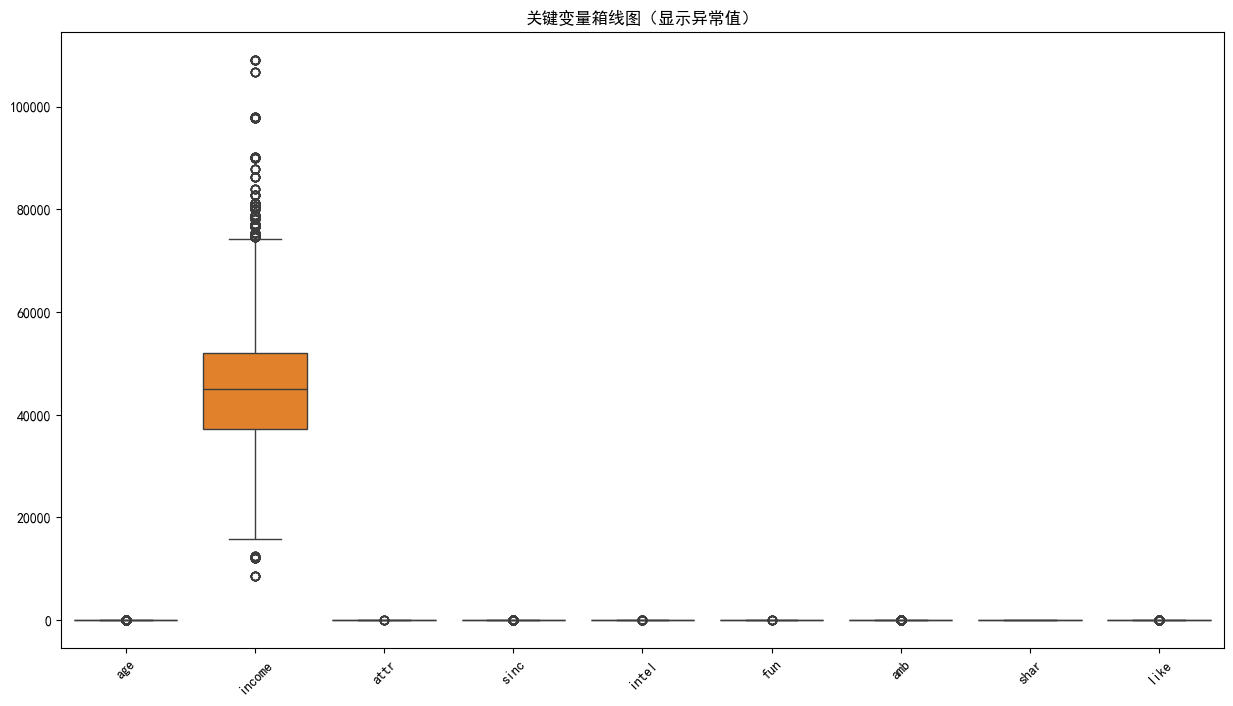

In [18]:
# 绘制箱线图查看异常值
plt.figure(figsize=(15, 8))
sns.boxplot(data=data_cleaned[key_numeric_cols])
plt.title('关键变量箱线图（显示异常值）')
plt.xticks(rotation=45)
plt.show()

### 4.3 处理异常值

对于异常值，采用以下策略：
- **年龄**：使用中位数替换异常值
- **收入**：使用中位数替换异常值
- **评分类变量**（attr, sinc, intel等）：已有范围限制(0-10)，无需额外处理

使用 Winsorization 方法（缩尾处理）将异常值替换为边界值。

In [19]:
# Winsorization处理异常值
def winsorize_column(df, column, lower_percentile=0.01, upper_percentile=0.99):
    lower_bound = df[column].quantile(lower_percentile)
    upper_bound = df[column].quantile(upper_percentile)
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

# 对年龄和收入进行缩尾处理
data_cleaned = winsorize_column(data_cleaned, 'age')
data_cleaned = winsorize_column(data_cleaned, 'income')

print("缩尾处理完成")

缩尾处理完成



处理后的统计摘要:


,age,income
count,8378.00,8378.00
mean,26.32,45357.43
std,3.37,13123.87
min,20.00,16875.57
25%,24.00,37248.00
50%,26.00,44996.23
75%,28.00,52010.00
max,36.00,86340.00


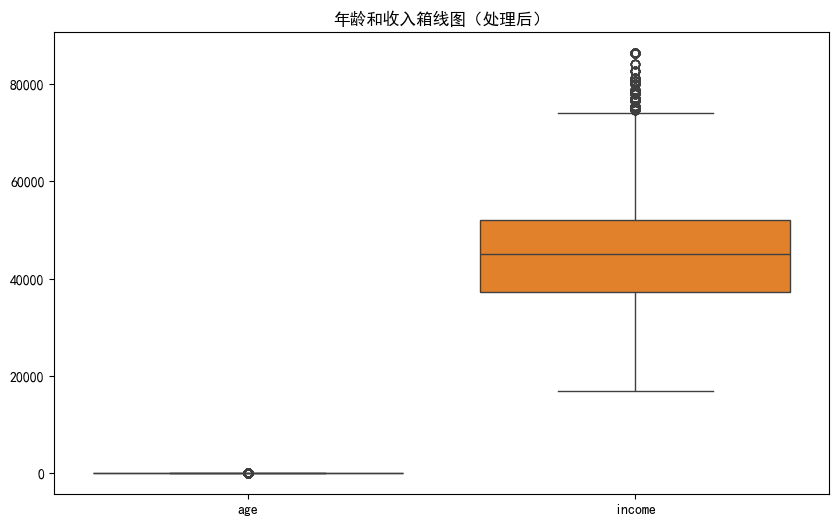

In [20]:
# 验证处理后的结果
print("\n处理后的统计摘要:")
display(data_cleaned[['age', 'income']].describe().round(2))

# 再次绘制箱线图
plt.figure(figsize=(10, 6))
sns.boxplot(data=data_cleaned[['age', 'income']])
plt.title('年龄和收入箱线图（处理后）')
plt.show()

---

## 5. 数据处理结果总结

In [21]:
# 数据处理前后对比
print("数据处理结果总结:")
print(f"原始数据: {data.shape[0]} 行, {data.shape[1]} 列")
print(f"处理后数据: {data_cleaned.shape[0]} 行, {data_cleaned.shape[1]} 列")
print(f"删除的行数: {data.shape[0] - data_cleaned.shape[0]}")
print(f"删除的列数: {data.shape[1] - data_cleaned.shape[1]}")
print(f"剩余缺失值: {data_cleaned.isnull().sum().sum()}")

数据处理结果总结:
原始数据: 8378 行, 195 列
处理后数据: 8378 行, 136 列
删除的行数: 0
删除的列数: 59
剩余缺失值: 0


In [22]:
# 保存处理后的数据
data_cleaned.to_csv('Speed Dating Data Cleaned.csv', index=False, encoding='utf-8')
print("\n处理后的数据已保存为 'Speed Dating Data Cleaned.csv'")


处理后的数据已保存为 'Speed Dating Data Cleaned.csv'


---

## 附录：使用的方法说明

### 数据描述方法
- `shape`: 查看数据集维度
- `dtypes`: 查看数据类型
- `describe()`: 数值型数据统计摘要
- `value_counts()`: 分类变量频率统计
- `isnull().sum()`: 缺失值统计

### 数据转换方法
- `astype('category')`: 将数值型转换为类别型
- `drop_duplicates()`: 去除重复数据


### 缺失值处理方法
- 高缺失率列处理: 删除缺失率>50%的列

- 数值型插补: 提供了以下的方法

| 方法 | 一句话简介 | 优点 | 缺点 |
| --- | --- | --- | --- |
| 中位数插补 | 将缺失值替换为变量的中位数 | 简单快速、对异常值鲁棒 | 忽略变量间关系、可能低估方差 |
| KNN 插补 | 根据相似样本的特征值进行插补 | 考虑变量间关系、保留数据分布 | 对距离敏感、计算量大 |
| MICE 插补 | 通过链式方程迭代预测缺失值 | 最准确、工业标准、处理复杂关系 | 计算量大、需要完整数据 |
| 随机森林插补 | 用随机森林模型预测缺失值 | 处理非线性关系、鲁棒性强 | 计算量大、可能过拟合 |

- 类别型插补: 提供了以下的方法

| 方法 | 一句话简介 | 优点 | 缺点 |
| --- | --- | --- | --- |
| 众数插补 | 将缺失值替换为出现次数最多的类别 | 简单快速、保持类别分布 | 忽略变量间关系、可能引入偏差 |
| 创建"缺失"类别 | 将缺失值作为独立类别处理 | 保留缺失信息、不引入偏差 | 增加类别数量、可能影响模型 |
| 分类模型插补 | 用分类算法预测缺失的类别值 | 考虑变量间关系、预测准确 | 计算量大、需要足够训练数据 |

### 异常值处理方法
- **IQR方法**: 识别异常值的标准方法
- **Winsorization**: 缩尾处理，将极端值替换为百分位数边界值
- 保留评分类变量在0-10范围内